<a href="https://colab.research.google.com/github/VaggelisApostolou/Project2---Mining-from-Massive-Datasets/blob/main/Project2DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [ ]:
!pip install "numpy<2.0" tslearn -q
!git clone https://github.com/TheDatumOrg/TSB-UAD.git

fatal: destination path 'TSB-UAD' already exists and is not an empty directory.


---
### ⚠️ ΠΡΟΣΟΧΗ: Απαιτείται Επανεκκίνηση (Restart Session) ⚠️

Λόγω ασυμβατότητας του μοντέλου SAND με το `numpy 2.0`, το παραπάνω κελί εγκαθιστά μια συμβατή έκδοση (`numpy<2.0`). Για να τεθεί σε ισχύ η αλλαγή στη μνήμη του Colab, **πρέπει να γίνει επανεκκίνηση**.

**Οδηγίες:**
1. Πηγαίνετε στο μενού πάνω: **Runtime (Χρόνος εκτέλεσης)** -> **Restart session (Επανεκκίνηση...)**.
2. Πατήστε "Ναι" στο παράθυρο που θα εμφανιστεί.
3. **ΜΗΝ** ξανατρέξετε το Κελί 1. Ξεκινήστε την εκτέλεση κατευθείαν από το **Κελί 2** και κάτω.
---

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import warnings
warnings.filterwarnings('ignore')

#SAND import
if '/content/TSB-UAD' not in sys.path:
    sys.path.append('/content/TSB-UAD')
try:
    from TSB_UAD.models.sand import SAND
    print("SAND imported successfully\n")
except Exception as e:
    print(f"Error during SAND import {e}\n")

SAND imported successfully



# **Datasets Creation**

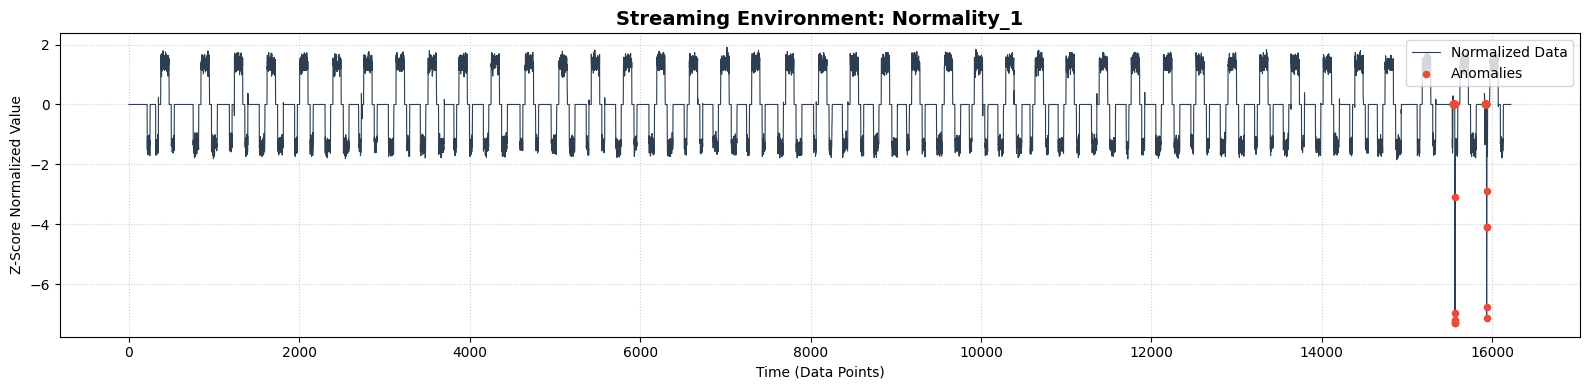

Saved to: Normality_1.csv



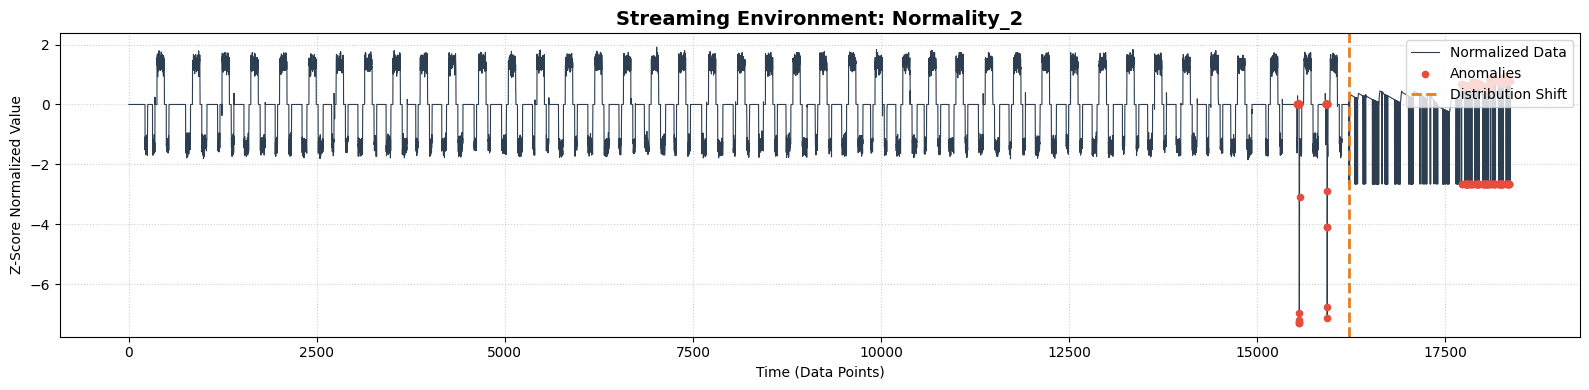

Saved to: Normality_2.csv



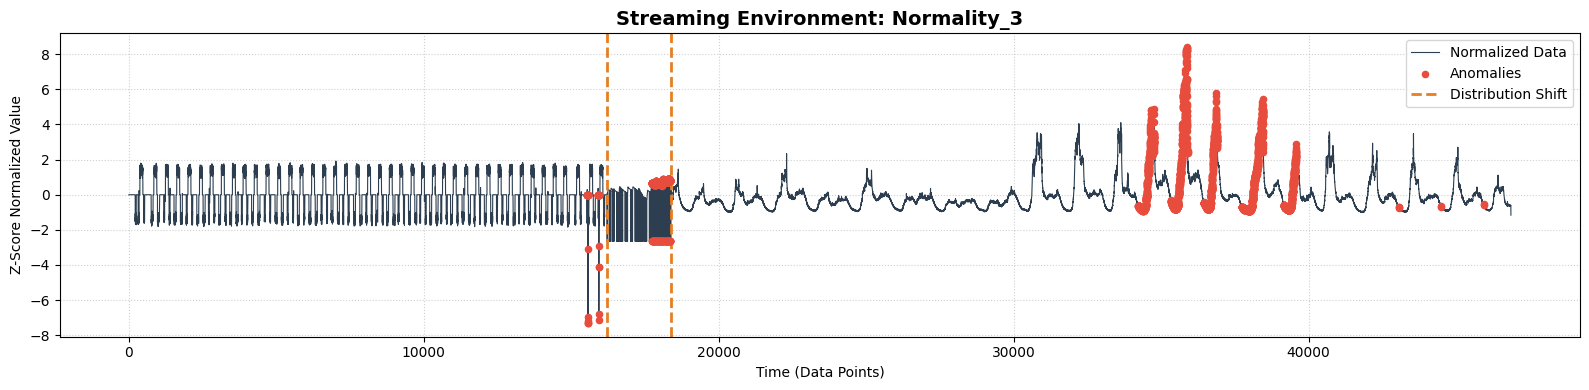

Saved to: Normality_3.csv



(array([-0.00240651, -0.00240651, -0.00240651, ..., -0.61974684,
        -0.70472371, -1.16527806]),
 array([0, 0, 0, ..., 0, 0, 0]))

In [ ]:
def load_and_normalize_ts(file_path):

    df = pd.read_csv(file_path, header=None, sep=',')
    values = df.iloc[:, 0].values.reshape(-1, 1)
    labels = df.iloc[:, 1].values.astype(int)

    # z-score
    scaler = StandardScaler()
    normalized_values = scaler.fit_transform(values).flatten()

    return normalized_values, labels

#timeseries concatenation and distribution shifts
def create_streaming_environment(file_paths, stream_name):

    all_values = []
    all_labels = []
    shift_points = []

    current_length = 0
    for file_path in file_paths:
        vals, labs = load_and_normalize_ts(file_path)
        all_values.extend(vals)
        all_labels.extend(labs)

        current_length += len(vals)
        shift_points.append(current_length)

    all_values = np.array(all_values)
    all_labels = np.array(all_labels)

    #plots --> black line is normalized data, red dots are anomalies and orange line is distribution shift
    plt.figure(figsize=(16, 4), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')
    plt.plot(all_values, label="Normalized Data", color="#2c3e50", linewidth=0.8)
    anomalies_idx = np.where(all_labels == 1)[0]
    if len(anomalies_idx) > 0:
        plt.scatter(anomalies_idx, all_values[anomalies_idx], color="#e74c3c", s=20, label="Anomalies", zorder=3)
    for idx, p in enumerate(shift_points[:-1]):
        plt.axvline(x=p, color='#e67e22', linestyle='--', linewidth=2,
                    label="Distribution Shift" if idx == 0 else "")

    plt.title(f"Streaming Environment: {stream_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Data Points)")
    plt.ylabel("Z-Score Normalized Value")
    handles, labels_leg = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    #save to csv
    out_df = pd.DataFrame({'value': all_values, 'label': all_labels})
    out_filename = f"{stream_name}.csv"
    out_df.to_csv(out_filename, index=False)
    print(f"Saved to: {out_filename}\n")

    return all_values, all_labels



#Normality 1 (Genesis)
normality1_files = ['genesis-anomalies.test.csv@3.out']
create_streaming_environment(normality1_files, "Normality_1")

#Normality 2 (Genesis - NASA-MSL)
normality2_files = ['genesis-anomalies.test.csv@3.out', 'D-15.test.out']
create_streaming_environment(normality2_files, "Normality_2")

#Normality 3 (Genesis - NASA-MSL - SMD)
normality3_files = ['genesis-anomalies.test.csv@3.out', 'D-15.test.out', 'machine-1-1.test.csv@20.out']
create_streaming_environment(normality3_files, "Normality_3")

# **Visualization**

In [ ]:
experiment_results = []

def log_result(dataset_name, model_name, auc, runtime):
    experiment_results.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "AUC-ROC": auc,
        "Runtime (sec)": runtime
    })

def generate_poster_plots():
    df = pd.DataFrame(experiment_results)
    if df.empty: return
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 14})
    metrics = ["AUC-ROC", "Runtime (sec)"]
    for metric in metrics:
        plt.figure(figsize=(14, 6), facecolor='white')
        ax = sns.barplot(data=df, x="Dataset", y=metric, hue="Model", palette="Set2")
        plt.title(f"Models comparison: {metric}", fontweight='bold', pad=20)
        plt.ylabel(metric, fontweight='bold')
        plt.xlabel("Streaming Environment", fontweight='bold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', xytext=(0, 5),
                            textcoords='offset points', fontsize=10, rotation=45)
        plt.tight_layout()
        filename = f"Poster_Plot_{metric.replace(' ', '_').replace('/', '_')}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
        plt.show()

# **Isolation Forest & Autoencoder**


 ---Evaluation in: Normality_1.csv---
Isolation Forest AUC-ROC: 0.138 | Execution Time: 0.43s
Autoencoder AUC-ROC: 0.690 | Execution Time: 6.67s


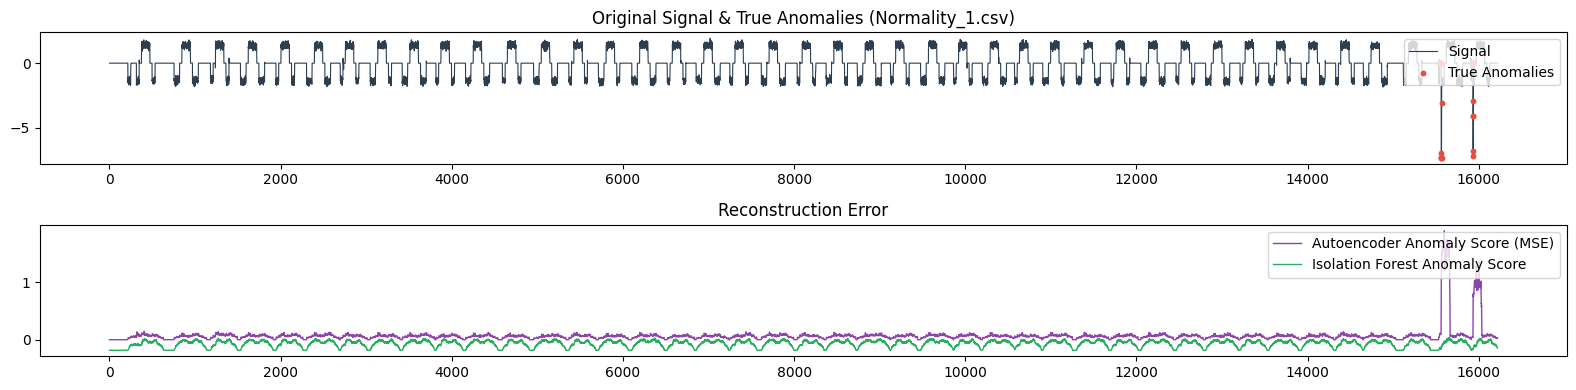


 ---Evaluation in: Normality_2.csv---
Isolation Forest AUC-ROC: 0.924 | Execution Time: 0.44s
Autoencoder AUC-ROC: 0.964 | Execution Time: 5.48s


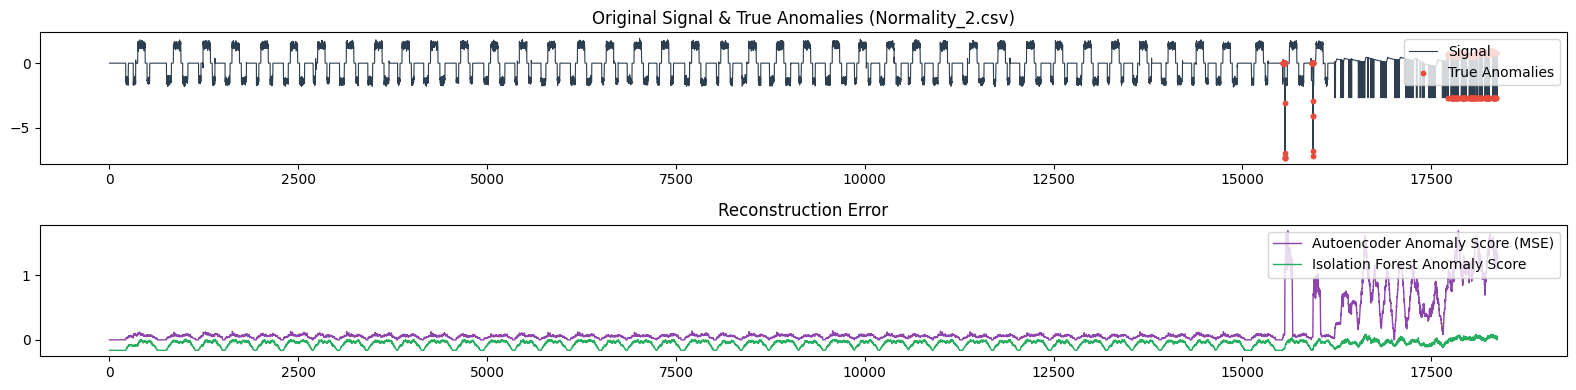


 ---Evaluation in: Normality_3.csv---
Isolation Forest AUC-ROC: 0.629 | Execution Time: 0.90s
Autoencoder AUC-ROC: 0.540 | Execution Time: 11.61s


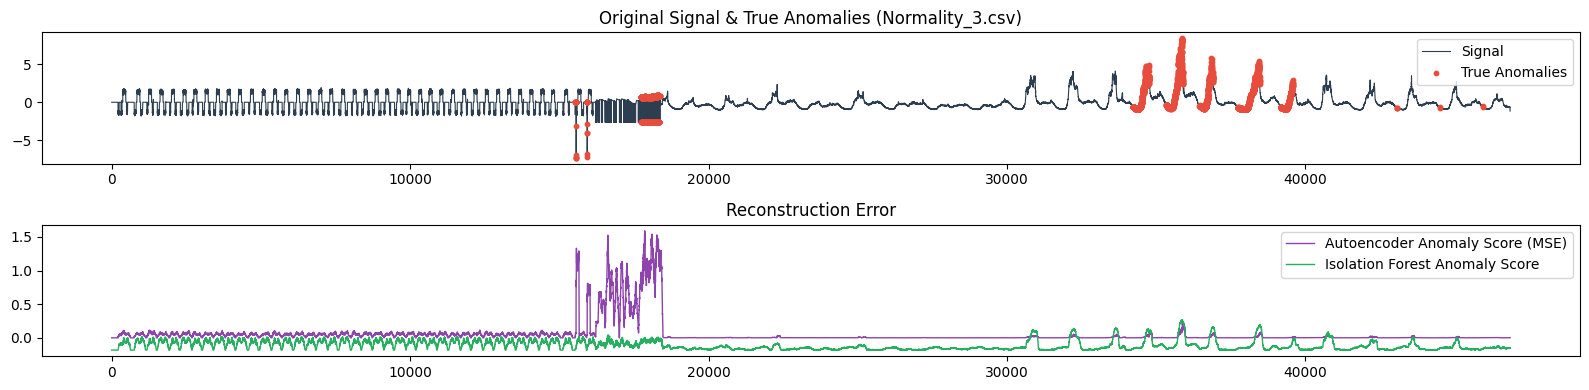

In [ ]:
#create sliding window
def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i + window_size])
    return np.array(windows)

#scores padding
def pad_scores(scores, original_length, window_size):
    padded = np.zeros(original_length)
    padded[window_size - 1:] = scores
    padded[:window_size - 1] = scores[0] # Γεμίζουμε την αρχή με το πρώτο score
    return padded

#Autoencoder
def build_autoencoder(window_size):
    inputs = Input(shape=(window_size,))
    encoded = Dense(32, activation='relu')(inputs)
    encoded = Dense(16, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(window_size, activation='linear')(decoded)
    ae = Model(inputs, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae

# Evaluation
def evaluate_baselines(csv_file, window_size=100):
    print(f"\n ---Evaluation in: {csv_file}---")
    df = pd.read_csv(csv_file)
    data = df['value'].values
    labels = df['label'].values
    X = create_windows(data, window_size)

    # 1st model: Isolation Forest
    start_time_if = time.time()
    iforest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    iforest.fit(X)
    if_scores_windows = -iforest.decision_function(X)
    if_scores = pad_scores(if_scores_windows, len(data), window_size)
    exec_time_if = time.time() - start_time_if

    # 2nd model: Autoencoder
    start_time_ae = time.time()
    ae = build_autoencoder(window_size)
    ae.fit(X, X, epochs=5, batch_size=64, validation_split=0.1, verbose=0)
    X_pred = ae.predict(X, verbose=0)
    # anomaly score=MSE of reconstruction
    ae_scores_windows = np.mean(np.power(X - X_pred, 2), axis=1)
    ae_scores = pad_scores(ae_scores_windows, len(data), window_size)
    exec_time_ae = time.time() - start_time_ae


    #AUC-ROC
    if np.sum(labels) > 0:
        if_auc = roc_auc_score(labels, if_scores)
        ae_auc = roc_auc_score(labels, ae_scores)
        print(f"Isolation Forest AUC-ROC: {if_auc:.3f} | Execution Time: {exec_time_if:.2f}s")
        print(f"Autoencoder AUC-ROC: {ae_auc:.3f} | Execution Time: {exec_time_ae:.2f}s")
    else:
        print("No anomalies in the dataset.")
        if_auc, ae_auc = None, None
    log_result(csv_file, "Offline Isolation Forest", if_auc, exec_time_if)
    log_result(csv_file, "Offline Autoencoder", ae_auc, exec_time_ae)

    plt.figure(figsize=(16, 4), facecolor='white')
    ax1 = plt.subplot(211)
    ax1.plot(data, color='#2c3e50', linewidth=0.8, label="Signal")
    anomalies = np.where(labels == 1)[0]
    ax1.scatter(anomalies, data[anomalies], color='#e74c3c', s=10, label="True Anomalies", zorder=3)
    ax1.set_title(f"Original Signal & True Anomalies ({csv_file})")
    ax1.legend(loc='upper right')

    ax2 = plt.subplot(212, sharex=ax1)
    ax2.plot(ae_scores, color='#8e44ad', linewidth=1, label="Autoencoder Anomaly Score (MSE)")
    ax2.plot(if_scores, color='#27ae60', linewidth=1, label="Isolation Forest Anomaly Score")
    ax2.set_title("Reconstruction Error")
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

#Run in 3 datasets
datasets = ["Normality_1.csv", "Normality_2.csv", "Normality_3.csv"]
window_size = 100

for dataset in datasets:
    evaluate_baselines(dataset, window_size)

# **SAND**


---SAND evaluation in: Normality_1.csv---
Running SAND with batch_size=500
SAND AUC-ROC: 0.908 | Execution Time: 84.87s


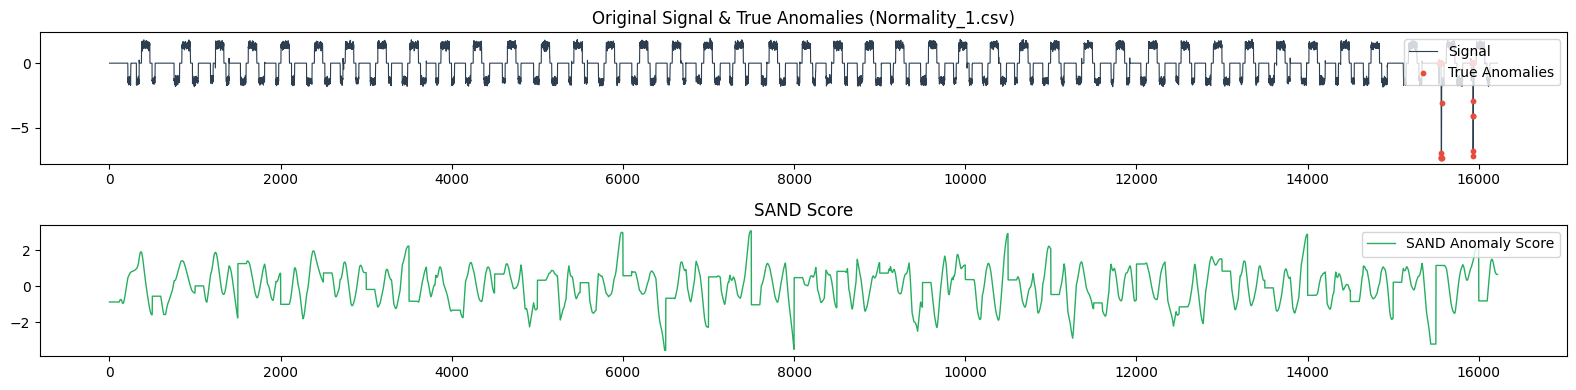


---SAND evaluation in: Normality_2.csv---
Running SAND with batch_size=500
SAND AUC-ROC: 0.601 | Execution Time: 29.90s


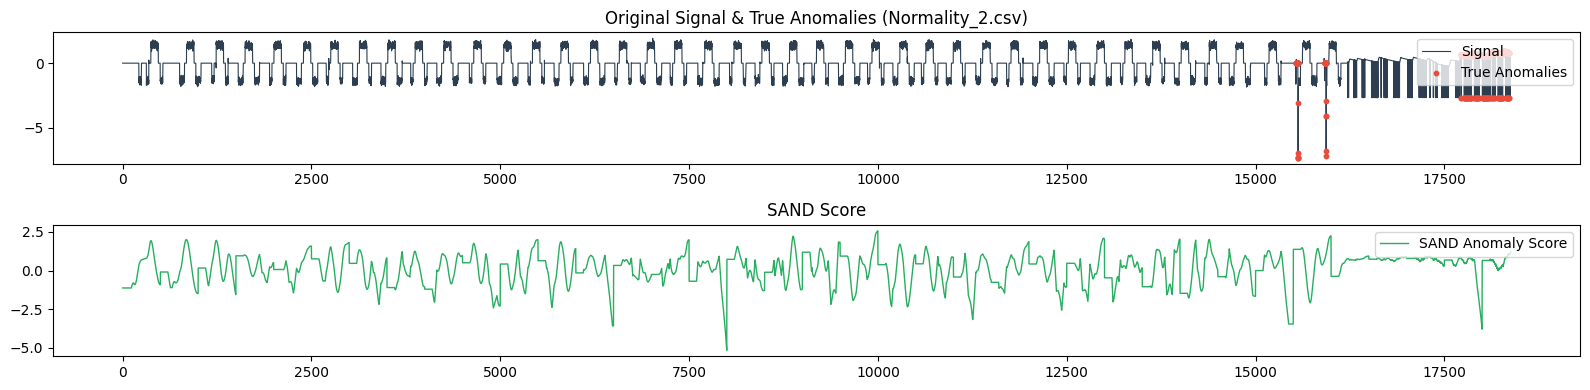


---SAND evaluation in: Normality_3.csv---
Running SAND with batch_size=500
SAND AUC-ROC: 0.487 | Execution Time: 115.26s


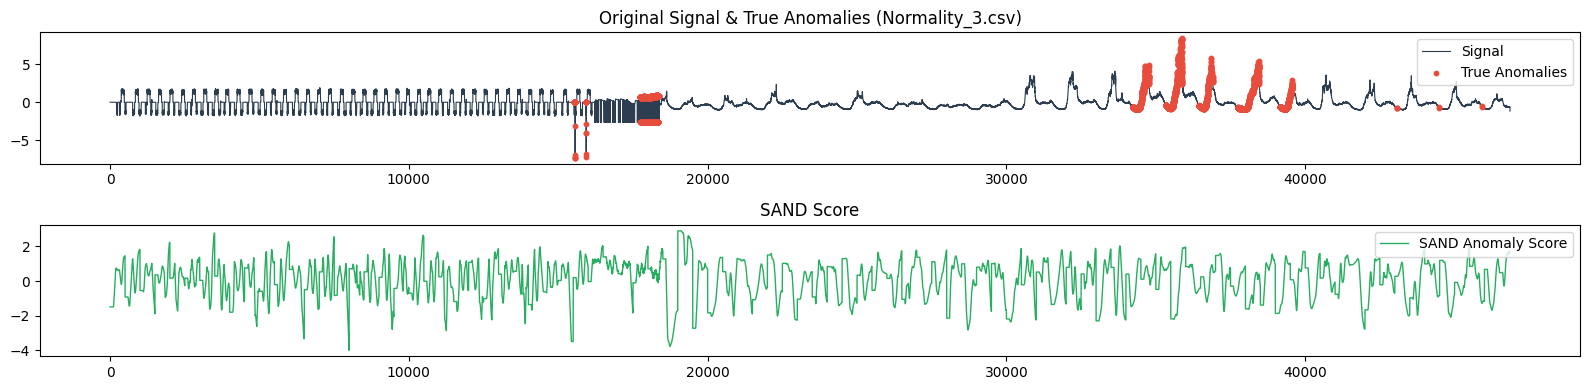

In [ ]:
def evaluate_sand_streaming(csv_file, batch_size=500, subsequence_length=100):
    print(f"\n---SAND evaluation in: {csv_file}---")
    df = pd.read_csv(csv_file)
    data = df['value'].values
    labels = df['label'].values
    sand_model = SAND(pattern_length=subsequence_length, subsequence_length=subsequence_length)
    print(f"Running SAND with batch_size={batch_size}")
    start_time = time.time()
    sand_model.fit(data, online=True, alpha=0.5, init_length=batch_size, batch_size=batch_size)
    scores = sand_model.decision_scores_
    padded_scores = np.zeros(len(data))
    diff = len(data) - len(scores)
    if diff > 0:
        padded_scores[diff:] = scores
        padded_scores[:diff] = scores[0]
    else:
        padded_scores = scores[:len(data)]
    exec_time = time.time() - start_time

    if np.sum(labels) > 0:
        auc = roc_auc_score(labels, padded_scores)
        log_result(csv_file, "SAND", auc, exec_time)
        print(f"SAND AUC-ROC: {auc:.3f} | Execution Time: {exec_time:.2f}s")
    else:
        print("No anomalies")

    #plots
    plt.figure(figsize=(16, 4), facecolor='white')
    ax1 = plt.subplot(211)
    ax1.plot(data, color='#2c3e50', linewidth=0.8, label="Signal")
    anomalies = np.where(labels == 1)[0]
    ax1.scatter(anomalies, data[anomalies], color='#e74c3c', s=10, label="True Anomalies", zorder=3)
    ax1.set_title(f"Original Signal & True Anomalies ({csv_file})")
    ax1.legend(loc='upper right')
    ax2 = plt.subplot(212, sharex=ax1)
    ax2.plot(padded_scores, color='#27ae60', linewidth=1, label="SAND Anomaly Score")
    ax2.set_title("SAND Score")
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

#Run in 3 datasets
datasets = ["Normality_1.csv", "Normality_2.csv", "Normality_3.csv"]
window_size = 100
for dataset in datasets:
    evaluate_sand_streaming(dataset, batch_size=500, subsequence_length=window_size)

# **Variants**

In [ ]:
def create_windows(data, window_size):
    windows = [data[i:i + window_size] for i in range(len(data) - window_size + 1)]
    return np.array(windows)

def pad_scores(scores, original_length, window_size):
    padded = np.zeros(original_length)
    padded[window_size - 1:] = scores
    padded[:window_size - 1] = scores[0]
    return padded

def build_autoencoder(window_size):
    inputs = Input(shape=(window_size,))
    encoded = Dense(32, activation='relu')(inputs)
    encoded = Dense(16, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(window_size, activation='linear')(decoded)
    ae = Model(inputs, decoded)
    ae.compile(optimizer='adam', loss='mse')
    return ae


# Autoencoder variants
def evaluate_ae_naive(csv_file, batch_size=500, window_size=100):
    print(f"---Evaluation for Variant 1 (Naive Autoencoder)---")
    df = pd.read_csv(csv_file)
    data, labels = df['value'].values, df['label'].values
    num_batches = len(data) // batch_size
    all_scores = np.zeros(len(data))

    start_time = time.time()
    for i in range(num_batches + 1):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(data))
        batch_data = data[start_idx:end_idx]
        if len(batch_data) < window_size: continue
        X_batch = create_windows(batch_data, window_size)

        #New model for each batch
        ae = build_autoencoder(window_size)
        ae.fit(X_batch, X_batch, epochs=3, batch_size=32, verbose=0)
        X_pred = ae.predict(X_batch, verbose=0)
        batch_scores = pad_scores(np.mean(np.power(X_batch - X_pred, 2), axis=1), len(batch_data), window_size)
        all_scores[start_idx:end_idx] = batch_scores

    exec_time = time.time() - start_time
    if np.sum(labels) > 0:
        print(f"Naive AE AUC-ROC: {roc_auc_score(labels, all_scores):.3f} | Time: {exec_time:.2f} sec\n")
        log_result(csv_file, "Variant 1 (Naive AE)", roc_auc_score(labels, all_scores), exec_time)

def evaluate_ae_incremental(csv_file, batch_size=500, window_size=100):
    print(f"---Evaluation for Variant 2 (Incremental Autoencoder)---")
    df = pd.read_csv(csv_file)
    data, labels = df['value'].values, df['label'].values
    num_batches = len(data) // batch_size
    all_scores = np.zeros(len(data))
    start_time = time.time()
    ae = build_autoencoder(window_size)
    for i in range(num_batches + 1):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(data))
        batch_data = data[start_idx:end_idx]
        if len(batch_data) < window_size: continue
        X_batch = create_windows(batch_data, window_size)

        #fine-tuning
        ae.fit(X_batch, X_batch, epochs=1, batch_size=32, verbose=0)
        X_pred = ae.predict(X_batch, verbose=0)
        batch_scores = pad_scores(np.mean(np.power(X_batch - X_pred, 2), axis=1), len(batch_data), window_size)
        all_scores[start_idx:end_idx] = batch_scores

    exec_time = time.time() - start_time
    if np.sum(labels) > 0:
        print(f"Incremental AE AUC-ROC: {roc_auc_score(labels, all_scores):.3f} | Time: {exec_time:.2f} sec\n")
        log_result(csv_file, "Variant 2 (Incremental AE)", roc_auc_score(labels, all_scores), exec_time)


# Isolation Forest variants
def evaluate_iforest_naive(csv_file, batch_size=500, window_size=100):
    print(f"---Evaluation for Variant 1 (Naive iForest)---")
    df = pd.read_csv(csv_file)
    data, labels = df['value'].values, df['label'].values
    num_batches = len(data) // batch_size
    all_scores = np.zeros(len(data))
    start_time = time.time()
    for i in range(num_batches + 1):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(data))
        batch_data = data[start_idx:end_idx]
        if len(batch_data) < window_size: continue
        X_batch = create_windows(batch_data, window_size)
        iforest = IsolationForest(n_estimators=50, random_state=42)
        iforest.fit(X_batch)
        batch_scores = pad_scores(-iforest.decision_function(X_batch), len(batch_data), window_size)
        all_scores[start_idx:end_idx] = batch_scores

    exec_time = time.time() - start_time
    if np.sum(labels) > 0:
        print(f"Naive iForest AUC-ROC: {roc_auc_score(labels, all_scores):.3f} | Time: {exec_time:.2f} sec\n")
        log_result(csv_file, "Variant 1 (Naive iForest)", roc_auc_score(labels, all_scores), exec_time)

def evaluate_iforest_buffer(csv_file, batch_size=500, window_size=100, buffer_batches=3):
    print(f"---Evaluation for Variant 2 (Sliding Buffer iForest)---")
    df = pd.read_csv(csv_file)
    data, labels = df['value'].values, df['label'].values
    num_batches = len(data) // batch_size
    all_scores = np.zeros(len(data))
    memory_buffer = []
    max_memory_size = batch_size * buffer_batches
    start_time = time.time()
    for i in range(num_batches + 1):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(data))
        batch_data = data[start_idx:end_idx]
        if len(batch_data) < window_size: continue

        #memory buffer
        memory_buffer.extend(batch_data)
        if len(memory_buffer) > max_memory_size:
            memory_buffer = memory_buffer[-max_memory_size:]
        X_train_buffer = create_windows(memory_buffer, window_size)
        iforest = IsolationForest(n_estimators=50, random_state=42)
        iforest.fit(X_train_buffer)
        X_test_batch = create_windows(batch_data, window_size)
        batch_scores = pad_scores(-iforest.decision_function(X_test_batch), len(batch_data), window_size)
        all_scores[start_idx:end_idx] = batch_scores

    exec_time = time.time() - start_time
    if np.sum(labels) > 0:
        print(f"Buffer iForest AUC-ROC: {roc_auc_score(labels, all_scores):.3f} | Time: {exec_time:.2f} sec\n")
        log_result(csv_file, "Variant 2 (Buffer iForest)", roc_auc_score(labels, all_scores), exec_time)

In [ ]:
# Results
datasets_to_test = ["Normality_1.csv", "Normality_2.csv", "Normality_3.csv"]
for dataset in datasets_to_test:
    print(f"\n{'='*70}\n Results for: {dataset}\n{'='*70}")
    evaluate_iforest_naive(dataset)
    evaluate_iforest_buffer(dataset)
    evaluate_ae_naive(dataset)
    evaluate_ae_incremental(dataset)


 Results for: Normality_1.csv
---Evaluation for Variant 1 (Naive iForest)---
Naive iForest AUC-ROC: 0.174 | Time: 3.25 sec

---Evaluation for Variant 2 (Sliding Buffer iForest)---
Buffer iForest AUC-ROC: 0.279 | Time: 3.95 sec

---Evaluation for Variant 1 (Naive Autoencoder)---
Naive AE AUC-ROC: 0.660 | Time: 61.45 sec

---Evaluation for Variant 2 (Incremental Autoencoder)---


Incremental AE AUC-ROC: 0.681 | Time: 9.29 sec


 Results for: Normality_2.csv
---Evaluation for Variant 1 (Naive iForest)---
Naive iForest AUC-ROC: 0.468 | Time: 3.59 sec

---Evaluation for Variant 2 (Sliding Buffer iForest)---
Buffer iForest AUC-ROC: 0.589 | Time: 5.42 sec

---Evaluation for Variant 1 (Naive Autoencoder)---
Naive AE AUC-ROC: 0.920 | Time: 81.96 sec

---Evaluation for Variant 2 (Incremental Autoencoder)---
Incremental AE AUC-ROC: 0.948 | Time: 12.95 sec


 Results for: Normality_3.csv
---Evaluation for Variant 1 (Naive iForest)---
Naive iForest AUC-ROC: 0.538 | Time: 11.52 sec

---Evaluation for Variant 2 (Sliding Buffer iForest)---
Buffer iForest AUC-ROC: 0.614 | Time: 12.86 sec

---Evaluation for Variant 1 (Naive Autoencoder)---
Naive AE AUC-ROC: 0.681 | Time: 197.19 sec

---Evaluation for Variant 2 (Incremental Autoencoder)---
Incremental AE AUC-ROC: 0.569 | Time: 25.90 sec



# **Plots**

Saved: Poster_Plot_AUC-ROC.png


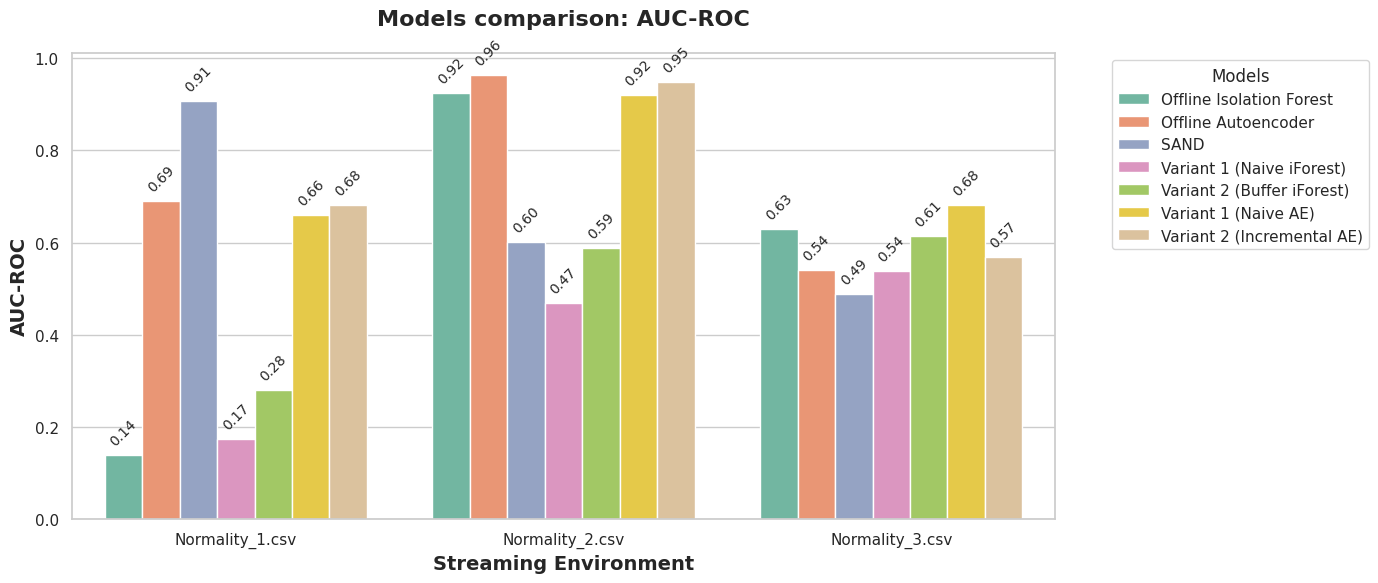

Saved: Poster_Plot_Runtime_(sec).png


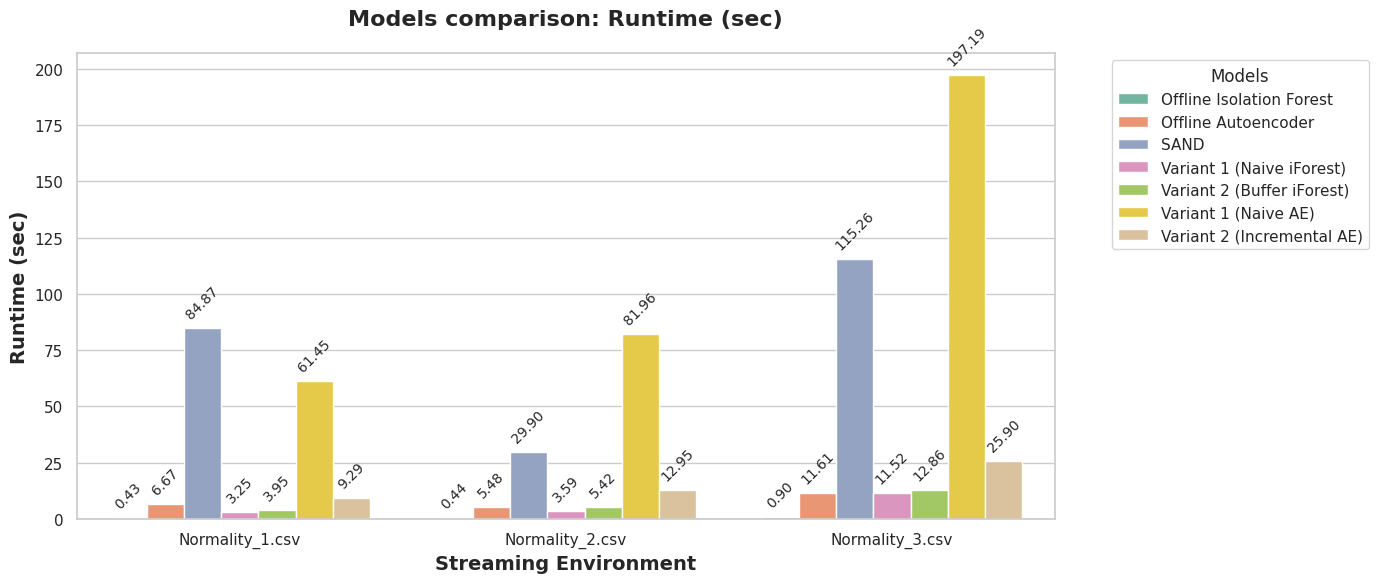

In [ ]:
generate_poster_plots()